# Semi-Parametric Example: Setup with Systematic Uncertainties

Based on the MadMiner physics tutorial by Johann Brehmer, Felix Kling, Irina Espejo, and Kyle Cranmer.

This notebook sets up a MadMiner analysis for VBF Higgs production (h -> gamma gamma) with **all available systematic uncertainties** enabled:

- **Scale variations** (QCD renormalization/factorization): `mu`, `mur`, `muf`
- **PDF uncertainty**: varying the PDF set (e.g., NNPDF31)
- **Normalization uncertainty**: per-sample cross-section rescaling

All systematics propagate into joint likelihood ratios and scores via MadMiner's `NuisanceMorpher`, enabling full nuisance-aware inference.

## 0. Preparations

In [1]:
import os
import logging

MadMiner uses the Python `logging` module to provide additional information and debugging output. You can choose how much of this output you want to see by switching the level in the following lines to `logging.DEBUG` or `logging.WARNING`.

In [2]:
# MadMiner output
logging.basicConfig(
    format="%(asctime)-5.5s %(name)-20.20s %(levelname)-7.7s %(message)s",
    datefmt="%H:%M",
    level=logging.INFO,
)

# Output of all other modules (e.g. matplotlib)
for key in logging.Logger.manager.loggerDict:
    if "madminer" not in key:
        logging.getLogger(key).setLevel(logging.WARNING)

In [3]:
from madminer import MadMiner, plot_2d_morphing_basis

## 1. Input data

As an example process, we'll simulate VBF Higgs production with a decay into two photons. We'll try to measure two EFT coefficients that affect this process.

Have a look at the `cards` folder. You'll find text files ("cards") that specify the process simulation in typical MadGraph convention.

## 2. Define parameter space

After creating a `MadMiner` instance, the first important step is the definition of the parameter space. Each model parameter is characterized by a name as well as the LHA block and ID.

If morphing is used, one also has to specify the maximal power with which the parameter contributes to the squared matrix element. For instance, a parameter that contributes only to one vertex, will typically have `morphing_max_power=2`, while a parameter that contributes to two vertices usually has `morphing_max_power=4`. Exceptions arise for instance when the interference effects between the SM and dimension-six operators are modelled, but the square of the dimension-six amplitude (subleading in 1/Lambda) is not taken into account, in which case `morphing_max_power=1`. The `parameter_range` argument defines the range of parameter values that are used for the automatic optimization of the morphing basis.

Finally, the parameter values theta used internally by MadMiner and the parameter values written to the param_card (or reweight_card) given to MadGraph do not have to be exactly the same. With the option `parm_card_transform`, the user can supply a one-parameter function that maps a parameter value theta to the value given to MadGraph. This string is a python expression, in which `theta` is parsed as the parameter value. For instance, if the internal parameters are in the range (0, 1), but should be linearly scaled to (0, 100) in the param_card, one would have to use `param_card_transform="100*theta"`.

In [4]:
miner = MadMiner()

miner.add_parameter(
    lha_block="dim6",
    lha_id=2,
    parameter_name="CWL2",
    morphing_max_power=2,
    param_card_transform="16.52*theta",
    parameter_range=(-20.0, 20.0),
)
miner.add_parameter(
    lha_block="dim6",
    lha_id=5,
    parameter_name="CPWL2",
    morphing_max_power=2,
    param_card_transform="16.52*theta",
    parameter_range=(-20.0, 20.0),
)

17:03 madminer.core.madmin INFO    Adding parameter: CWL2 (LHA: dim6 2, Power: 2, Range: (-20.0, 20.0))
17:03 madminer.core.madmin WARNING Resetting benchmarks and morphing
17:03 madminer.core.madmin INFO    Adding parameter: CPWL2 (LHA: dim6 5, Power: 2, Range: (-20.0, 20.0))
17:03 madminer.core.madmin WARNING Resetting benchmarks and morphing


## 3. Define benchmarks manually

The next step is the definition of all the points at which the weights (squared matrix elements) should be evaluated by MadGraph. We call these points "benchmarks". One can define benchmarks by hand:

In [5]:
miner.add_benchmark({"CWL2": 0.0, "CPWL2": 0.0}, "sm")
miner.add_benchmark({"CWL2": 15.2, "CPWL2": 0.1}, "w")
miner.add_benchmark({"CWL2": -15.4, "CPWL2": 0.2}, "neg_w")
miner.add_benchmark({"CWL2": 0.3, "CPWL2": 15.1}, "ww")
miner.add_benchmark({"CWL2": 0.4, "CPWL2": -15.3}, "neg_ww")

17:03 madminer.core.madmin INFO    Added benchmark sm: CWL2 = 0.00e+00, CPWL2 = 0.00e+00
17:03 madminer.core.madmin INFO    Added benchmark w: CWL2 = 15.20, CPWL2 = 0.10
17:03 madminer.core.madmin INFO    Added benchmark neg_w: CWL2 = -1.54e+01, CPWL2 = 0.20
17:03 madminer.core.madmin INFO    Added benchmark ww: CWL2 = 0.30, CPWL2 = 15.10
17:03 madminer.core.madmin INFO    Added benchmark neg_ww: CWL2 = 0.40, CPWL2 = -1.53e+01


## 4. Morphing

Morphing is a powerful technique that allows for the fast and exact interpolation of event weights (or any derived quantity) from a set of original benchmark points (the "morphing basis") to anywhere in theory parameter space. This procedure depends on the powers with which the parameters affect the differential cross sections (this is why `add_parameter()` wants to know about this). Please see Sec. II.C.2 of ["A Guide to Constraining Effective Field Theories With Machine Learning"](https://arxiv.org/abs/1805.00020) for an explanation of the technique.

Morphing is not strictly necessary to run MadMiner, but it makes life easier in so many ways (and many methods are so far only implemented for morphing-based problems). We strongly recommend to use this wherever possible.

To activate morphing, the function `set_morphing` has to be called. With the option `include_existing_benchmarks=True`, MadMiner will keep all the benchmark points defined beforehand and run a simple optimization algorithm to fix the remaining ones for the basis (which may be none). Otherwise, MadMiner will optimize the full basis and forget about all previously defined benchmark points.

The other important keyword is `max_overall_power`. This sets the maximal combined power with which all parameters together contribute to the squared matrix element (cross section). This constraint is in addition to the `morphing_max_power` keyword of `add_parameter()` (see above). For instance, if there are two parameters of interest `a` and `b`, and it is known that there are contributions proportional to `1` (constant), `a`, `a^2`, `b`, `b^2`, and `ab`, then `max_overall_power=2`. If there are also contributions proportional to `a^2 b`, `a b^2`, and `a^2 b^2`, then `max_overall_power=4`.

In [6]:
miner.set_morphing(include_existing_benchmarks=True, max_overall_power=2)

17:03 madminer.core.madmin INFO    Optimizing basis for morphing
17:03 madminer.core.madmin INFO    Set up morphing with 2 parameters, 6 morphing components, 5 predefined basis points, and 1 new basis points


Let's have a look at the resulting morphing basis and the "morphing error", i.e. the sum of squared morphing weights as a function of the parameter space. The black dots mark the benchmarks at which the squared matrix element will be evaluated when MadGraph is run. In between them, the morphing will interpolate. Since the morphing knows about the functional form of the amplitudes, there is only a small numerical uncertainty in this interpolation, we expect that the color in this plot is indicative of this uncertainty.

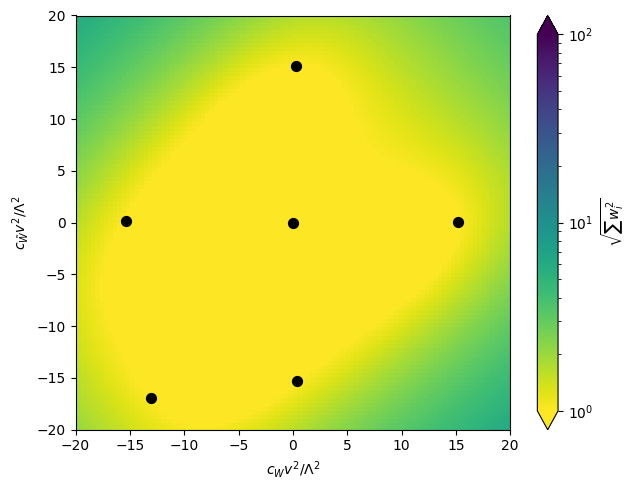

In [7]:
fig = plot_2d_morphing_basis(
    miner.morpher,
    xlabel=r"$c_{W} v^2 / \Lambda^2$",
    ylabel=r"$c_{\tilde{W}} v^2 / \Lambda^2$",
    xrange=(-20.0, 20.0),
    yrange=(-20.0, 20.0),
)

Note that squared weights (the colormap here) up to 1000 or even 10000 can still be perfectly fine and are in fact sometimes unavoidable.

## 5. Add systematic uncertainties

We add all available systematic uncertainty types:

1. **Scale** (`effect="scale"`): QCD renormalization (`mur`) and factorization (`muf`) scale variations, treated independently. MadGraph computes event weight variations for each.
2. **PDF** (`effect="pdf"`): Parton distribution function uncertainty from LHAPDF Hessian eigenvectors. Creates one nuisance parameter per eigenvector direction.
3. **Norm** (`effect="norm"`): Overall cross-section normalization uncertainty, applied analytically (not via MadGraph).

All types create nuisance parameters that propagate into joint scores and likelihood ratios.

**Note**: MadGraph allows at most one `mur`, one `muf`, and one `pdf` systematic per run. Using `scale="mu"` (correlated mur+muf) would block separate mur/muf variations, so we use independent variations for maximum granularity.

In [8]:
# Scale systematics: vary mu_r independently
miner.add_systematics(
    effect="scale",
    systematic_name="scale_mur",
    scale="mur",
    scale_variations=(0.5, 2.0),
)

# Scale systematics: vary mu_f independently
miner.add_systematics(
    effect="scale",
    systematic_name="scale_muf",
    scale="muf",
    scale_variations=(0.5, 2.0),
)

# # PDF uncertainty (creates one nuisance parameter per PDF eigenvector)
# miner.add_systematics(
#     effect="pdf",
#     systematic_name="pdf_variation",
#     pdf_variation="NNPDF31_lo_as_0118",
# )

# Normalization uncertainties (one per sample)
miner.add_systematics(
    effect="norm",
    systematic_name="signal_norm",
    norm_variation=1.1,  # 10% uncertainty
)
miner.add_systematics(
    effect="norm",
    systematic_name="bkg_norm",
    norm_variation=1.2,  # 20% uncertainty
)

Save the complete setup including all systematics:

In [9]:
miner.save("data/setup_systematics.h5")

17:03 madminer.core.madmin INFO    Saving setup (including morphing) to data/setup_systematics.h5


## 6. Run MadGraph with systematics

MadMiner instructs MadGraph to use its built-in `systematics` tool to calculate event weight
variations under scale and PDF changes. Note that at most **one systematic per type** (scale-mu,
scale-mur, scale-muf, pdf) can be active per MadGraph run. NORM systematics don't affect
MadGraph — they are applied analytically during analysis.

**Important**: You need MadGraph 2.8.0+ with a Fortran compiler, and LHAPDF6 installed for PDF
variations. Set the `MG_FOLDER_PATH` environment variable to your MadGraph installation.

In [10]:
# mg_dir = os.getenv("MG_FOLDER_PATH")

In [11]:
mg_dir = "/home/jsandesara/MG5_aMC_v3_5_13"


### Signal generation

We pass all simulation-level systematics. MadGraph will generate weights for each variation.

In [13]:

miner.run(
    sample_benchmark="sm",
    mg_directory=mg_dir,
    mg_process_directory="./mg_processes/signal_systematics",
    proc_card_file="cards/proc_card_signal.dat",
    param_card_template_file="cards/param_card_template.dat",
    run_card_file="cards/run_card_signal_small.dat",
    log_directory="logs/signal",
    systematics=["signal_norm", "scale_mur", "scale_muf"],
)

17:03 madminer.utils.inter INFO    Generating MadGraph process folder from cards/proc_card_signal.dat at ./mg_processes/signal_systematics
17:03 madminer.utils.inter INFO    Calling MadGraph: /home/jsandesara/MG5_aMC_v3_5_13/bin/mg5_aMC /tmp/generate.mg5
17:03 madminer.core.madmin INFO    Run 0
17:03 madminer.core.madmin INFO      Sampling from benchmark: sm
17:03 madminer.core.madmin INFO      Original run card:       cards/run_card_signal_small.dat
17:03 madminer.core.madmin INFO      Original Pythia8 card:   None
17:03 madminer.core.madmin INFO      Original config card:    None
17:03 madminer.core.madmin INFO      Copied run card:         madminer/cards/run_card_0.dat
17:03 madminer.core.madmin INFO      Copied Pythia8 card:     None
17:03 madminer.core.madmin INFO      Copied config card:      None
17:03 madminer.core.madmin INFO      Param card:              madminer/cards/param_card_0.dat
17:03 madminer.core.madmin INFO      Reweight card:           madminer/cards/reweight_card_

### Background generation

In [ ]:
miner.run(
    sample_benchmark="sm",
    mg_directory=mg_dir,
    mg_process_directory="./mg_processes/bkg_systematics",
    proc_card_file="cards/proc_card_background.dat",
    param_card_template_file="cards/param_card_template.dat",
    run_card_file="cards/run_card_background.dat",
    log_directory="logs/background",
    python2_override=True,
    systematics=["bkg_norm", "scale_mur", "scale_muf"],
)

## 7. Load events and define observables

When adding LHE samples, use the `systematics` keyword to specify which uncertainties apply
to each sample. The LHE reader extracts nuisance benchmark weights from the MadGraph output.

In [ ]:
from madminer.lhe import LHEReader
from particle import Particle

lhe = LHEReader("data/setup_systematics.h5")

lhe.add_sample(
    lhe_filename="mg_processes/signal_systematics/Events/run_01/unweighted_events.lhe.gz",
    sampled_from_benchmark="sm",
    is_background=False,
    k_factor=1.1,
    systematics=["signal_norm", "scale_mur", "scale_muf"],
)

lhe.add_sample(
    lhe_filename="mg_processes/bkg_systematics/Events/run_01/unweighted_events.lhe.gz",
    sampled_from_benchmark="sm",
    is_background=True,
    k_factor=1.1,
    systematics=["bkg_norm", "scale_mur", "scale_muf"],
)

### Define observables, smearing, and cuts

In [ ]:
# Partons giving rise to jets
particles = [
    *Particle.findall(lambda p: p.pdgid.is_quark),
    *Particle.findall(pdg_name="g"),
]

lhe.set_smearing(
    pdgids=[int(p.pdgid) for p in particles],
    energy_resolution_abs=0.0,
    energy_resolution_rel=0.1,
    pt_resolution_abs=None,
    pt_resolution_rel=None,
    eta_resolution_abs=0.1,
    eta_resolution_rel=0.0,
    phi_resolution_abs=0.1,
    phi_resolution_rel=0.0,
)

lhe.add_observable("pt_j1", "j[0].pt", required=False, default=0.0)
lhe.add_observable(
    "delta_phi_jj",
    "j[0].deltaphi(j[1]) * (-1.0 + 2.0 * float(j[0].eta > j[1].eta))",
    required=True,
)
lhe.add_observable("met", "met.pt", required=True)

lhe.add_cut("(a[0] + a[1]).m > 122.0")
lhe.add_cut("(a[0] + a[1]).m < 128.0")
lhe.add_cut("pt_j1 > 30.0")

In [ ]:
lhe.analyse_samples()
lhe.save("data/lhe_data_systematics.h5")

## 8. Inspect systematic effects

Let's check the effect of nuisance parameters on observable distributions.

In [ ]:
import numpy as np
from madminer.plotting import plot_systematics

_ = plot_systematics(
    filename="data/lhe_data_systematics.h5",
    theta=np.array([0.0, 0.0]),
    observable="pt_j1",
    obs_label=r"$p_{T,j}$",
    obs_range=(30.0, 400.0),
    ratio_range=(0.7, 1.4),
)

_ = plot_systematics(
    filename="data/lhe_data_systematics.h5",
    theta=np.array([0.0, 0.0]),
    observable="delta_phi_jj",
    obs_label=r"$\Delta\phi_{jj}$",
    obs_range=(-3.1, 3.1),
    ratio_range=(0.7, 1.4),
)

## 9. Sample augmented training data

The `SampleAugmenter` with `include_nuisance_parameters=True` produces joint scores
that include gradients w.r.t. both physics parameters AND nuisance parameters.

Output score shape: `(n_samples, n_physics_params + n_nuisance_params)`

In [ ]:
from madminer.sampling import SampleAugmenter
from madminer import sampling

sampler = SampleAugmenter("data/lhe_data_systematics.h5", include_nuisance_parameters=True)

# SALLY-style: local score at SM
x, theta, t_xz, _ = sampler.sample_train_local(
    theta=sampling.benchmark("sm"),
    n_samples=100000,
    folder="./data/samples",
    filename="train_score_systematics",
)

print(f"Observables shape:  {x.shape}")
print(f"Parameters shape:   {theta.shape}")
print(f"Joint score shape:  {t_xz.shape}  (physics params + nuisance params)")

### Ratio-based sampling (for RASCAL, ALICE, etc.)

Joint likelihood ratios automatically include nuisance effects through the weight morphing.

In [ ]:
x, theta0, theta1, y, r_xz, t_xz0, t_xz1 = sampler.sample_train_ratio(
    theta0=sampling.random_morphing_points(100, [("sm",)]),
    theta1=sampling.benchmark("sm"),
    n_samples=100000,
    folder="./data/samples",
    filename="train_ratio_systematics",
)

print(f"Observables shape:     {x.shape}")
print(f"Joint ratio shape:     {r_xz.shape}")
print(f"Joint score shape:     {t_xz0.shape}  (physics params + nuisance params)")